In [7]:
from scipy.stats import ttest_1samp
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
#opening data
import os
import pathlib
import warnings
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [2]:
#open events
train = pd.DataFrame()
path = pathlib.Path('/home/ganesh/soccermatics/data/wyscout/events_England.json')
with open(path) as f:
    data = json.load(f)
train = pd.concat([train, pd.DataFrame(data)])

#open team data
path = pathlib.Path('/home/ganesh/soccermatics/data/wyscout/teams.json')
with open(path) as f:
    teams = json.load(f)

teams_df = pd.DataFrame(teams)
teams_df = teams_df.rename(columns={"wyId": "teamId"})

In [5]:
#get corners
corners = train.loc[train["subEventName"] == "Corner"]
#count corners by team
corners_by_team = corners.groupby(['teamId']).size().reset_index(name='counts')
#merge with team name
summary = corners_by_team.merge(teams_df[["name", "teamId"]], how = "left", on = ["teamId"])
#count corners by team by game
corners_by_game = corners.groupby(['teamId', "matchId"]).size().reset_index(name='counts')
#merge with team name
summary2 = corners_by_game.merge(teams_df[["name", "teamId"]], how = "left", on = ["teamId"])
summary2

,teamId,matchId,counts,name
0,1609,2499719,9,Arsenal
1,1609,2499735,9,Arsenal
2,1609,2499743,3,Arsenal
3,1609,2499749,10,Arsenal
4,1609,2499760,1,Arsenal
...,...,...,...,...
738,10531,2500056,6,Swansea City
739,10531,2500065,1,Swansea City
740,10531,2500076,1,Swansea City
741,10531,2500079,6,Swansea City


City typically had 7.50  plus/minus 3.28 corners per match in the 2017/18 season.


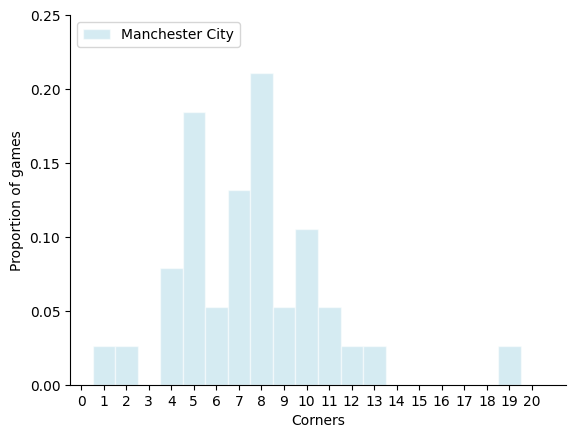

In [ ]:
team_name= 'Manchester City'

city_corners = summary2.loc[summary2["name"] == 'Manchester City']["counts"]

def FormatFigure(ax):
    ax.legend(loc='upper left')
    ax.set_ylim(0,0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('Corners')
    ax.set_ylabel('Proportion of games')
    ax.set_xticks(np.arange(0,21,step=1))


fig,ax1=plt.subplots(1,1)
ax1.hist(city_corners, np.arange(0.01,20.5,1), color='lightblue', edgecolor = 'white',linestyle='-',alpha=0.5, label=team_name, density=True,align='right')
FormatFigure(ax1)


mean = city_corners.mean()
std = city_corners.std()

print('City typically had %.2f  plus/minus %.2f corners per match in the 2017/18 season.'%(mean,std))

In [8]:
from scipy.stats import ttest_1samp
t, pvalue = ttest_1samp(city_corners,popmean=6)

print("The t-statistic is %.2f and the P-value is %.2f."%(t,pvalue))
if pvalue < 0.05:
    print("We reject null hypothesis - " + team_name + " typically take more than 6 corners per match.")
else:
    print("We cannot reject null hypothesis - " + team_name + " do not typically take more than 6 corners per match.")

The t-statistic is 2.82 and the P-value is 0.01.
We reject null hypothesis - Manchester City typically take more than 6 corners per match.


In [9]:
liverpool_corners = summary2.loc[summary2["name"] == 'Liverpool']["counts"]
everton_corners = summary2.loc[summary2["name"] == 'Everton']["counts"]

mean = liverpool_corners.mean()
std = liverpool_corners.std()
print('Liverpool typically had %.2f plus/minus %.2f corners per match in the 2017/18 season.'%(mean,std))
std_error=std/np.sqrt(len(liverpool_corners))
print('The standard error in the number of corners per match is %.4f'%std_error)

mean = everton_corners.mean()
std = everton_corners.std()
print('Everton typically had %.2f plus/minus %.2f corners per match in the 2017/18 season.'%(mean,std))
std_error=std/np.sqrt(len(everton_corners))
print('The standard error in the number of corners per match is %.4f'%std_error)

Liverpool typically had 6.08 plus/minus 3.06 corners per match in the 2017/18 season.
The standard error in the number of corners per match is 0.4966
Everton typically had 4.17 plus/minus 2.66 corners per match in the 2017/18 season.
The standard error in the number of corners per match is 0.4428


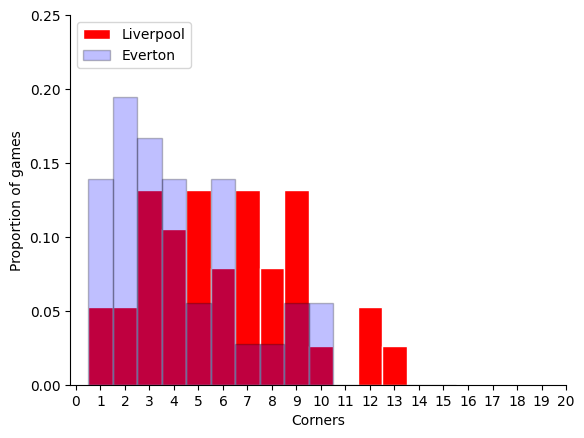

In [10]:
fig,ax=plt.subplots(1,1)
ax.hist(liverpool_corners, np.arange(0.01,15.5,1), color='red', edgecolor = 'white',linestyle='-',alpha=1.0, label="Liverpool", density=True,align='right')
ax.hist(everton_corners, np.arange(0.01,15.5,1), alpha=0.25, color='blue', edgecolor = 'black', label='Everton',  density=True,align='right')
FormatFigure(ax)

In [11]:
# Here we test if Liverpool had a different average corners per game than Everton.
# We set the significance level at 0.05.


from scipy.stats import ttest_ind
t, pvalue  = ttest_ind(a=liverpool_corners, b=everton_corners, equal_var=True)

print("The t-staistic is %.2f and the P-value is %.2f."%(t,pvalue))
if pvalue < 0.05:
    print("We reject null hypothesis - Liverpool took different number of corners per game than Everton")
else:
    print("We cannot reject the null hypothesis that Liverpool took the same number of corners per game as Everton")

The t-staistic is 2.86 and the P-value is 0.01.
We reject null hypothesis - Liverpool took different number of corners per game than Everton
